<a href="https://colab.research.google.com/github/Swastika-Roy/Python-concepts/blob/main/MissingDataAnalysisAndTreatment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/01_missing_values.csv')
print('Dataset shape: ',df.shape)
print("\\n" + "=" *80)
# print("Dataset Shape", df.shape)
print("Dimension", df.ndim)
print("Size", df.size)
print("Column Names",df.columns.tolist())
print("Index",df.index.tolist())
print("Data Types \n",df.dtypes)
df.describe()
print("Information about 'df'")
df.info()

Dataset shape:  (20, 11)
\n================================================================================
Dimension 2
Size 220
Column Names ['Employee_ID', 'First_Name', 'Last_Name', 'Email', 'Phone', 'Department', 'Salary', 'Hire_Date', 'Manager_ID', 'Office_Location', 'Years_Experience']
Index [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Data Types 
 Employee_ID          object
First_Name           object
Last_Name            object
Email                object
Phone                object
Department           object
Salary              float64
Hire_Date            object
Manager_ID           object
Office_Location      object
Years_Experience    float64
dtype: object
Information about 'df'
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Employee_ID       20 non-null     object 
 1   First_Name        16 no

In [ ]:
print("Missing Values")
#calculate
total_cells = df.size
miss = df.isnull().sum().sum()

print(f"dim : {df.shape[0]} rows x {df.shape[1]} cols" )
print(total_cells)
print(miss)
print(f"Missing Cells Percentage : {round((miss/total_cells)*100,2)}%")

Missing Values
dim : 20 rows x 11 cols
220
61
Missing Cells Percentage : 27.73%


In [ ]:
from pandas.core.dtypes.missing import notnull
from pandas.core.dtypes import dtypes
#detailed breakdown
#missing  values by col
missing_data = pd.DataFrame(
    {
        'col': df.columns,
        'missing_count': df.isnull().sum(),
        'missing_percentage': (df.isnull().sum() / len(df) * 100).round(2),
        'DATA-TYPE': df.dtypes,
        'Non-null-count': df.notnull().sum()
    }
)
miss_data = missing_data.sort_values(by='missing_percentage', ascending=False)
print(miss_data.to_string(index=False))

             col  missing_count  missing_percentage DATA-TYPE  Non-null-count
 Office_Location              8                40.0    object              12
           Email              7                35.0    object              13
       Hire_Date              7                35.0    object              13
      Manager_ID              7                35.0    object              13
          Salary              6                30.0   float64              14
           Phone              6                30.0    object              14
      Department              6                30.0    object              14
       Last_Name              5                25.0    object              15
Years_Experience              5                25.0   float64              15
      First_Name              4                20.0    object              16
     Employee_ID              0                 0.0    object              20


In [ ]:
print("missing values by row")
rows_with_missing_values = df[df.isnull().any(axis=1)]
print(f" {len(rows_with_missing_values)} out of {len(df)} rows have missing values ({len(rows_with_missing_values)/len(df)*100:.1f}%)")

missing values by row
 19 out of 20 rows have missing values (95.0%)


In [ ]:
print("_"*80)
print("Missing Value Patterns (Top 10)")
print("_"*80)

missing_patterns = df.isnull().groupby(df.isnull().apply(lambda x: tuple(x), axis=1)).size()
missing_patterns = missing_patterns.sort_values(ascending=False).head(10)
for i, (pattern, count) in enumerate(missing_patterns.items(),1):
    missing_cols = [col for col, is_missing in zip(df.columns,pattern) if is_missing]
    if missing_cols:
      print(f"{i}. Missing {missing_cols}: {count} rows")
    else:
      print(f"{i}. Complete rows : {count}")

________________________________________________________________________________
Missing Value Patterns (Top 10)
________________________________________________________________________________
1. Complete rows : 1
2. Missing ['Manager_ID']: 1 rows
3. Missing ['Department', 'Years_Experience']: 1 rows
4. Missing ['Department', 'Salary', 'Years_Experience']: 1 rows
5. Missing ['Phone', 'Salary', 'Manager_ID', 'Office_Location']: 1 rows
6. Missing ['Email', 'Hire_Date']: 1 rows
7. Missing ['Email', 'Hire_Date', 'Office_Location', 'Years_Experience']: 1 rows
8. Missing ['Email', 'Hire_Date', 'Manager_ID', 'Office_Location']: 1 rows
9. Missing ['Email', 'Department', 'Hire_Date', 'Office_Location']: 1 rows
10. Missing ['Email', 'Phone', 'Manager_ID', 'Office_Location']: 1 rows


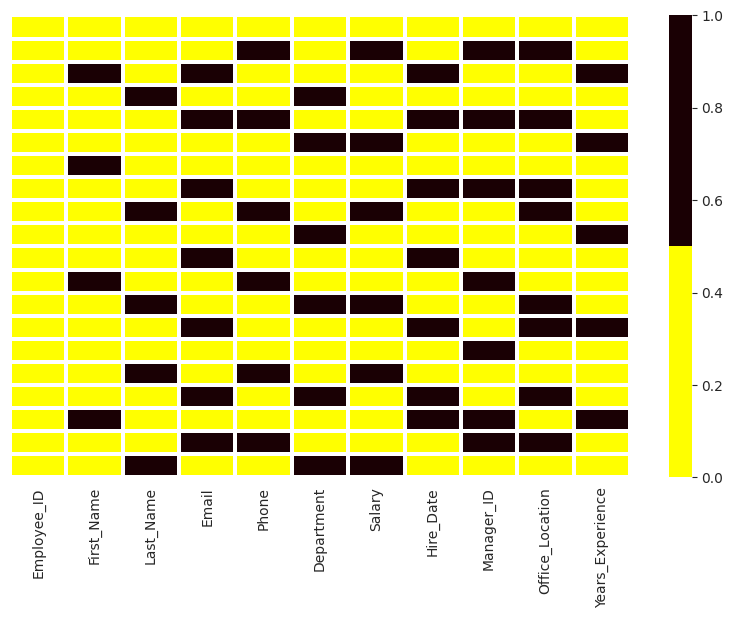

In [ ]:
sns.set_style('whitegrid')
#1 Missing Data heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar=True,cmap=['#FFFF00','#1A0004'],yticklabels=False,linewidths='1.5',linecolor='white')
plt.show()

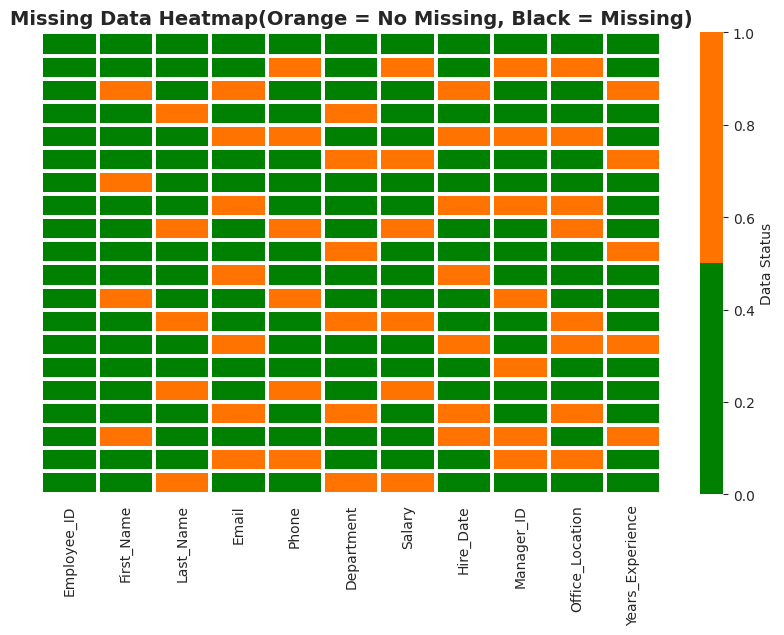

In [ ]:
sns.set_style('whitegrid')
#1 Missing Data heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=True, cmap=plt.cm.colors.ListedColormap(['green','#FF7400']),
            yticklabels=False, linewidths=1.5, linecolor='white',
            cbar_kws={'label':'Data Status'})
plt.title('Missing Data Heatmap(Orange = No Missing, Black = Missing)', fontsize=14, fontweight='bold')
plt.show()

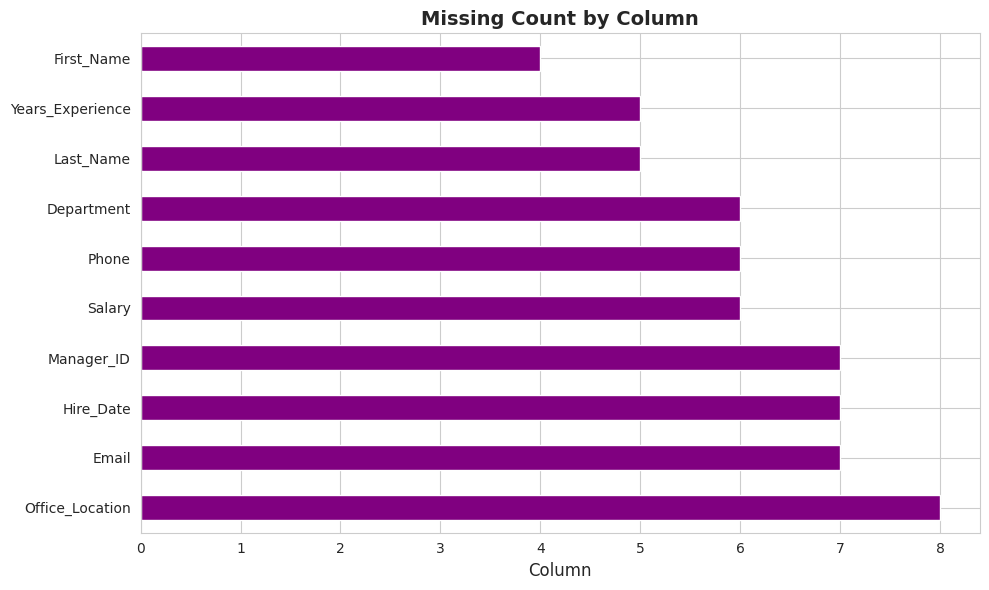

In [ ]:
#Missing Count by Column
plt.figure(figsize=(10,6))
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_count[missing_count>0].plot(kind='barh',color='purple')
plt.title('Missing Count by Column',fontsize=14,fontweight='bold')
plt.xlabel('Column',fontsize=12)
plt.tight_layout()
plt.show()

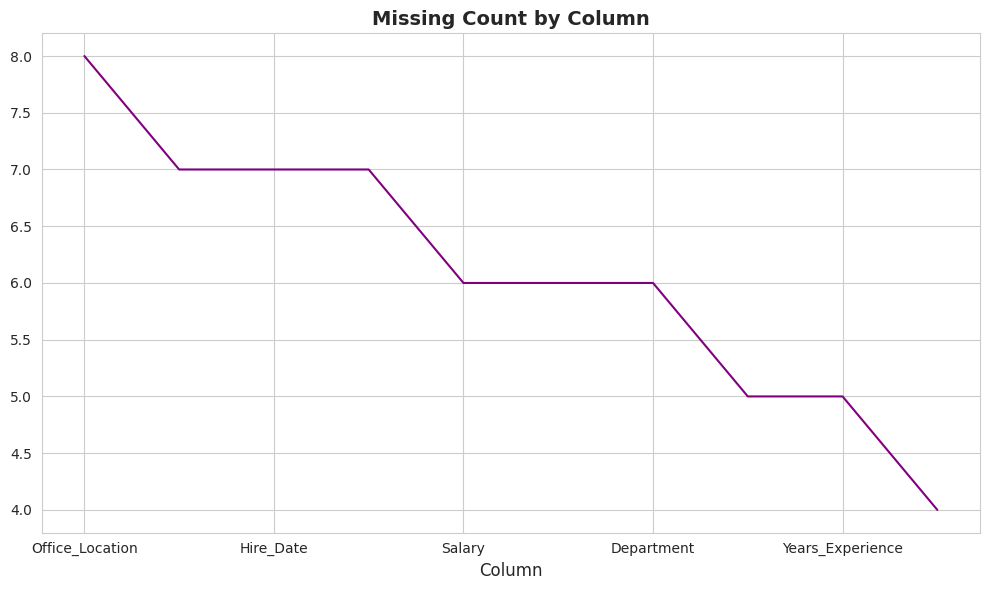

In [ ]:
#Missing Count by Column
plt.figure(figsize=(10,6))
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_count[missing_count>0].plot(color='purple')
plt.title('Missing Count by Column',fontsize=14,fontweight='bold')
plt.xlabel('Column',fontsize=12)
plt.tight_layout()
plt.show()

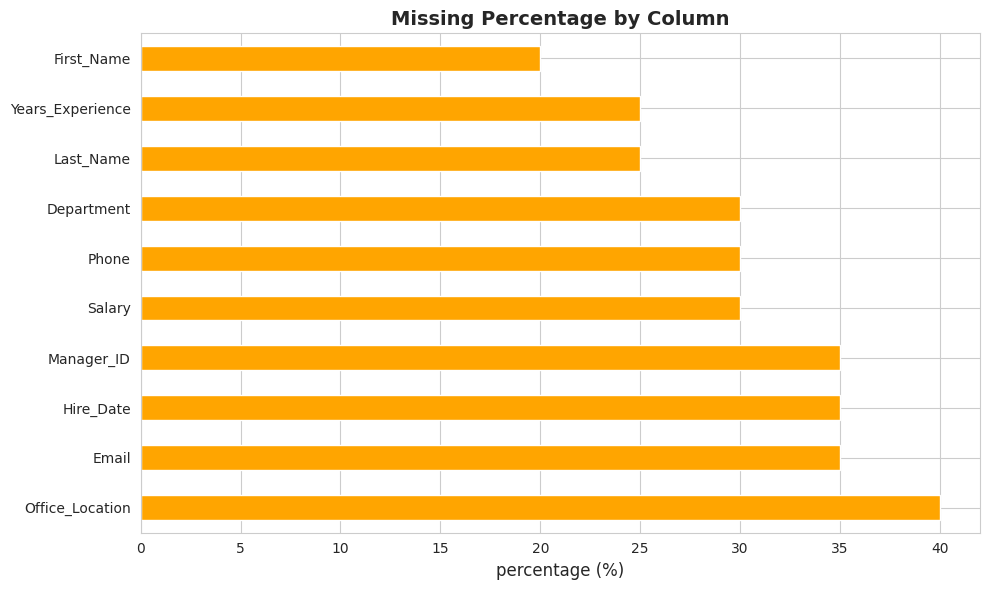

In [ ]:
#Missing percentage by Column
plt.figure(figsize=(10,6))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct>0].plot(kind='barh',color='orange')
plt.title('Missing Percentage by Column',fontsize=14,fontweight='bold')
plt.xlabel('percentage (%)',fontsize=12)
plt.tight_layout()
plt.show()

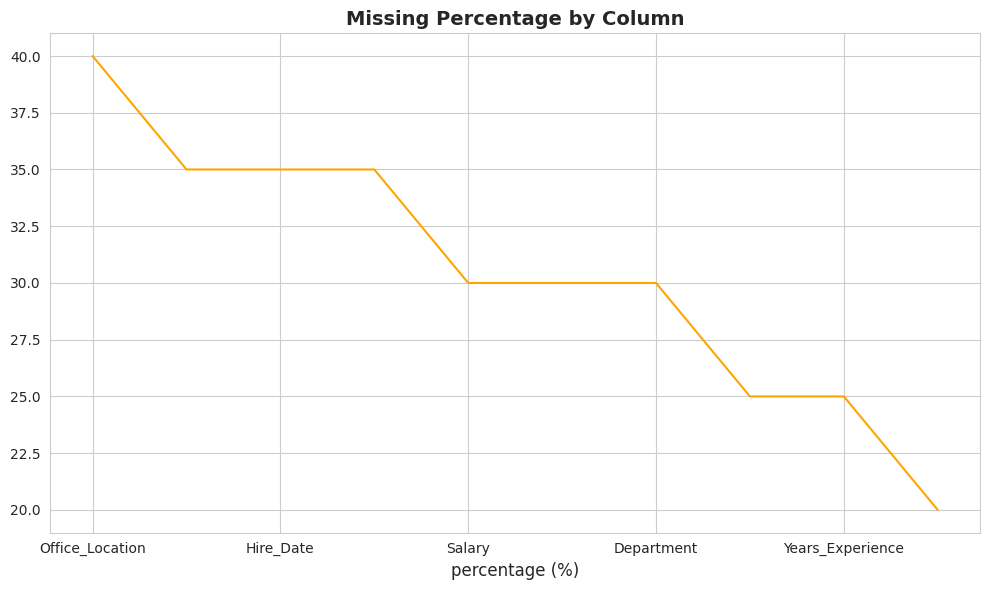

In [ ]:
#Missing percentage by Column
plt.figure(figsize=(10,6))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct>0].plot(color='orange')
plt.title('Missing Percentage by Column',fontsize=14,fontweight='bold')
plt.xlabel('percentage (%)',fontsize=12)
plt.tight_layout()
plt.show()

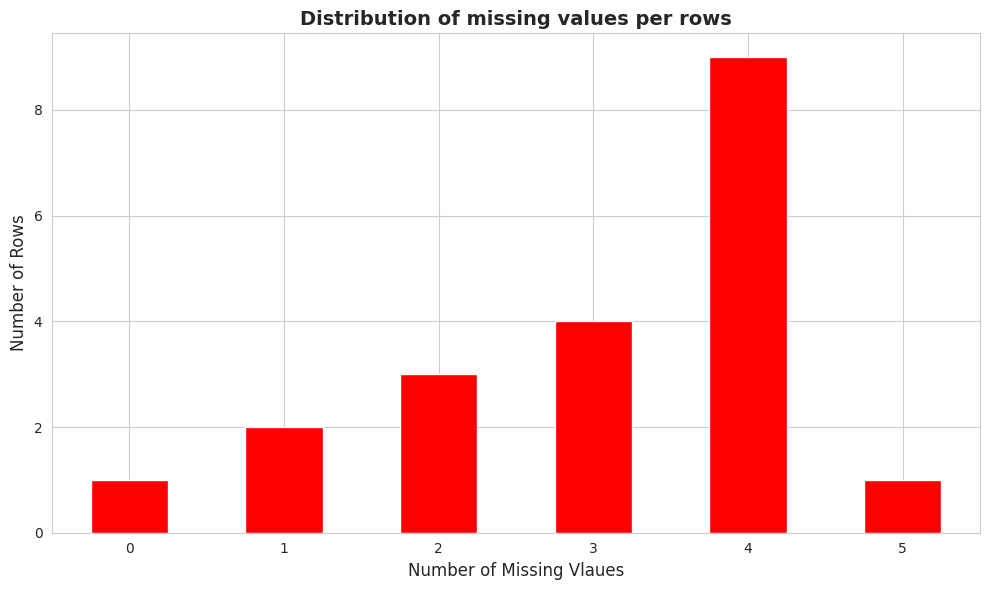

In [ ]:
#Missing Values per Row
plt.figure(figsize=(10,6))
missing_per_row = (df.isnull().sum(axis=1)).value_counts().sort_index()
missing_per_row[missing_per_row>0].plot(kind='bar',color='red')
plt.title('Distribution of missing values per rows',fontsize=14,fontweight='bold')
plt.xlabel('Number of Missing Vlaues',fontsize=12)
plt.ylabel('Number of Rows',fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

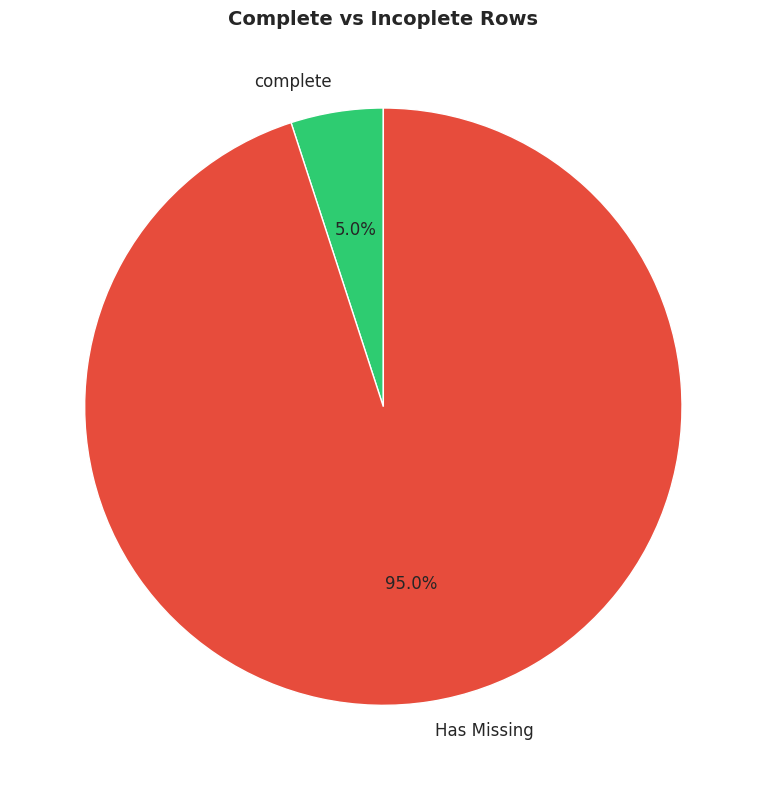

In [ ]:
plt.figure(figsize=(8,8))
complete_rows = df.notnull().all(axis=1).sum()
incomplete_rows = len(df) - complete_rows
plt.pie([complete_rows,incomplete_rows],
        labels = ['complete','Has Missing'],
        autopct = '%1.1f%%',
        colors = ['#2ECC71','#E74C3C'],
        startangle=90,
        textprops={'fontsize':12})
plt.title('Complete vs Incoplete Rows',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

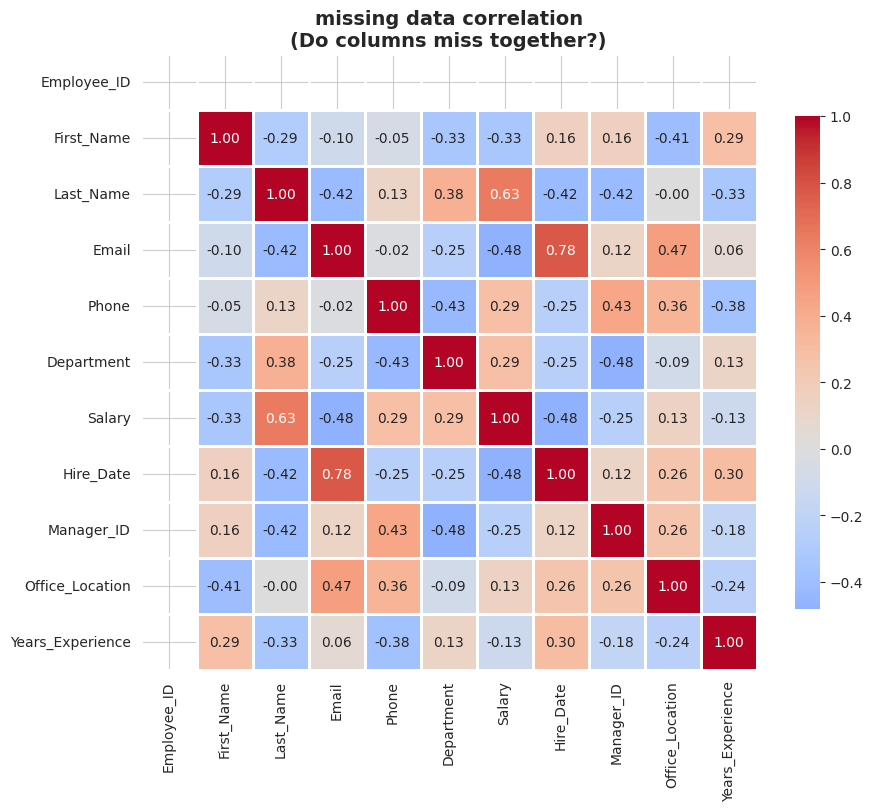

In [ ]:
#Missing data correlation
plt.figure(figsize=(10,8))
missing_corr = df.isnull().corr()
sns.heatmap(missing_corr,annot=True,fmt='.2f',cmap='coolwarm',center=0,square=True,linewidth=1,cbar_kws={"shrink":0.8})
plt.title('missing data correlation\n(Do columns miss together?)',fontsize=14,fontweight='bold')
plt.show()
#strong positive relationship : [hire_date,email][salary,last_name]
#strong negative relationship : [sal,hiredate][managerid,dept]

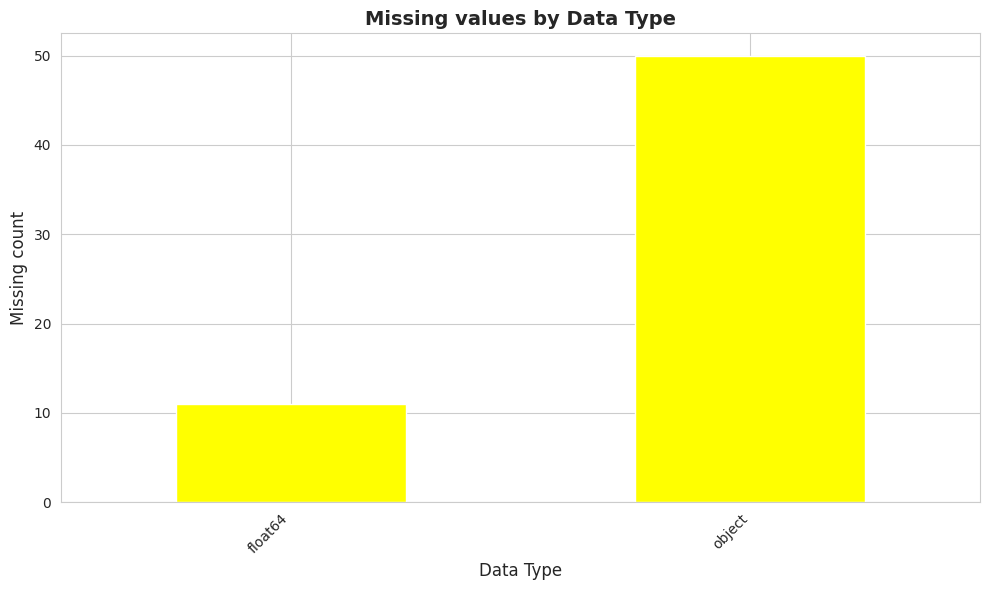

In [ ]:
#Missing values by Data Type
plt.figure(figsize=(10,6))
dtype_missing = df.isnull().sum().groupby(df.dtypes,group_keys=True).sum()
dtype_missing.plot(kind='bar',color='yellow')
plt.xlabel('Data Type',fontsize=12)
plt.ylabel('Missing count',fontsize=12)
plt.title('Missing values by Data Type',fontsize=14,fontweight='bold')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

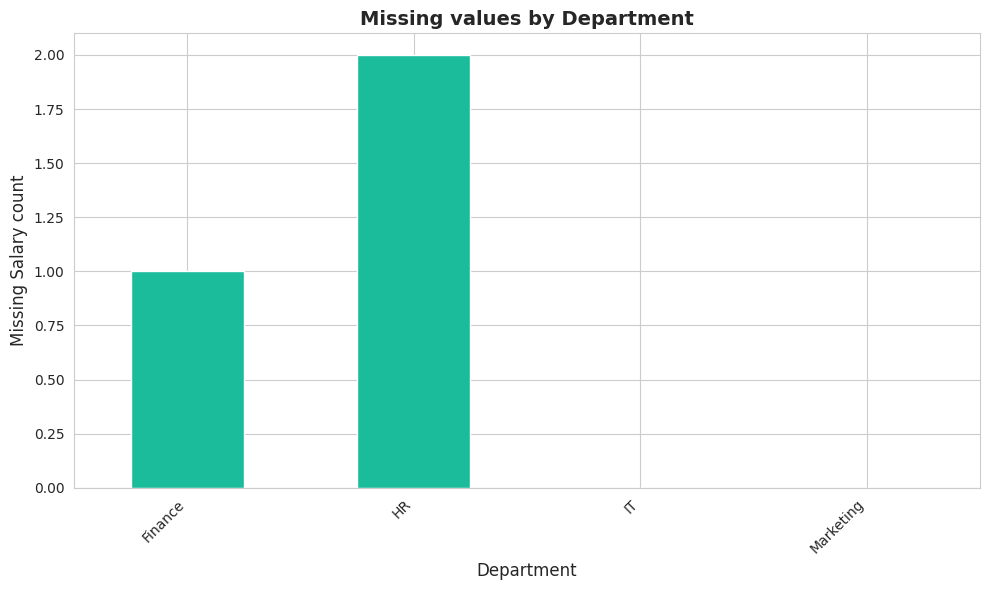

In [ ]:
from pandas._libs.tslibs.offsets import roll_qtrday
plt.figure(figsize=(10,6))
dept_salary_missing = df.groupby('Department')['Salary'].apply(lambda x : x.isnull().sum())
dept_salary_missing.plot(kind='bar',color='#1ABC9C')
plt.xlabel('Department',fontsize=12)
plt.ylabel('Missing Salary count',fontsize=12)
plt.title('Missing values by Department',fontsize=14,fontweight='bold')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.savefig('8_missing_salary_by_department.png',dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
# First_Name:
#   - Missing: 4 (20.0%)
#   - Type: object
#   - Recommended treatments:
#     • Mode imputation
#     • Fill with 'Unknown'
#     • Drop rows (if few)
# Last_Name:
#   - Missing: 5 (25.0%)
#   - Type: object
#   - Recommended treatments:
#     • Mode imputation
#     • Fill with 'Unknown'
#     • Drop rows (if few)
# Email:
#   - Missing: 7 (35.0%)
#   - Type: object
#   - Recommended treatments:
#     • Fill with 'Not Provided'
#     • Keep as missing (optional contact info)
# Phone:
#   - Missing: 6 (30.0%)
#   - Type: object
#   - Recommended treatments:
#     • Fill with 'Not Provided'
#     • Keep as missing (optional contact info)
# Department:
#   - Missing: 6 (30.0%)
#   - Type: object
#   - Recommended treatments:
#     • Mode imputation
#     • Predict based on other features
#     • Fill with 'Unassigned'
# Salary:
#   - Missing: 6 (30.0%)
#   - Type: float64
#   - Recommended treatments:
#     • Mean/Median by Department
#     • Overall median
#     • KNN imputation
# Hire_Date:
#   - Missing: 7 (35.0%)
#   - Type: object
#   - Recommended treatments:
#     • Mode or median date
#     • Keep as missing
# Manager_ID:
#   - Missing: 7 (35.0%)
#   - Type: object
#   - Recommended treatments:
#     • Mode or 'No Manager'
#     • Keep as missing (some may not have managers)
# Office_Location:
#   - Missing: 8 (40.0%)
#   - Type: object
#   - Recommended treatments:
#     • Mode imputation
#     • 'Remote' or 'Not Assigned'
# Years_Experience:
#   - Missing: 5 (25.0%)
#   - Type: float64
#   - Recommended treatments:
#     • Mean/Median by Department
#     • Derive from Hire_Date if available

In [ ]:
print("="*80)
print("METHOD 1: SIMPLE IMPUTATION")
print("="*80)
df_simple = df.copy()
df_simple['First_Name'].fillna('Unknown',inplace=True)
df_simple['Last_Name'].fillna('Unknown',inplace=True)
df_simple['Email'].fillna('not.provided@email.com',inplace=True)
df_simple['Phone'].fillna('Not Provided',inplace=True)

#fill with  catrgorial with mode
df_simple['Department'].fillna(df_simple['Department'].mode()[0],inplace=True)
df_simple['Manager_ID'].fillna(df_simple['Manager_ID'].mode()[0],inplace=True)
df_simple['Office_Location'].fillna(df_simple['Office_Location'].mode()[0],inplace=True)

#fill with numerial with medain
df_simple['Salary'].fillna(df_simple['Salary'].median(),inplace=True)
df_simple['Years_Experience'].fillna(df_simple['Years_Experience'].median(),inplace=True)

#fill date with mode
if not df_simple['Hire_Date'].mode().empty:
  df_simple['Hire_Date'].fillna(df_simple['Hire_Date'].mode()[0],inplace=True)

print(f"Missing values after simple imputation: {df_simple.isnull().sum().sum()}")
print("Sample of imputed data : ")
df_simple

METHOD 1: SIMPLE IMPUTATION
Missing values after simple imputation: 0
Sample of imputed data : 


,Employee_ID,First_Name,Last_Name,Email,Phone,Department,Salary,Hire_Date,Manager_ID,Office_Location,Years_Experience
0,E001,John,Smith,john.smith@email.com,555-0101,IT,50000.0,2020-01-15,M001,New York,5.0
1,E002,Sarah,Johnson,sarah.j@email.com,Not Provided,HR,55500.0,2019-06-20,M001,Boston,8.0
2,E003,Unknown,Williams,not.provided@email.com,555-0103,Finance,55000.0,2018-11-05,M002,Chicago,6.0
3,E004,Michael,Unknown,michael.w@email.com,555-0104,IT,60000.0,2021-03-10,M001,Boston,3.0
4,E005,Emma,Brown,not.provided@email.com,Not Provided,IT,48000.0,2018-11-05,M001,Boston,7.0
5,E006,David,Jones,david.jones@email.com,555-0106,IT,55500.0,2018-11-05,M003,Seattle,6.0
6,E007,Unknown,Garcia,garcia@email.com,555-0107,Marketing,52000.0,2020-07-22,M002,New York,4.0
7,E008,Lisa,Miller,not.provided@email.com,555-0108,IT,58000.0,2018-11-05,M001,Boston,9.0
8,E009,Robert,Unknown,robert@email.com,Not Provided,HR,55500.0,2019-09-14,M001,Boston,6.0
9,E010,Jennifer,Davis,jennifer.d@email.com,555-0110,IT,62000.0,2021-01-08,M003,Chicago,6.0


In [ ]:
print("="*80)
print("METHOD 2:    DELETION APPROACHES")
print("="*80)

#Drop all rows with any missing values
df_drop_all = df.dropna()
print(f"A. drop all rows with any missing : {len(df)} ->{len(df_drop_all)} rows ({len(df_drop_all)/len(df)*100:.1f}% remaining)")
df_drop_all

METHOD 2:    DELETION APPROACHES
A. drop all rows with any missing : 20 ->1 rows (5.0% remaining)


,Employee_ID,First_Name,Last_Name,Email,Phone,Department,Salary,Hire_Date,Manager_ID,Office_Location,Years_Experience
0,E001,John,Smith,john.smith@email.com,555-0101,IT,50000.0,2020-01-15,M001,New York,5.0


In [ ]:
#drop rows with missing critical fields
df_drop_critical = df.dropna(subset=['Employee_ID','Department','Salary'])
print(f"B. drop rows with missing critical fields : {len(df)} ->{len(df_drop_critical)} rows ({len(df_drop_critical)/len(df)*100:.1f}% remaining)")
df_drop_critical

B. drop rows with missing critical fields : 20 ->11 rows (55.0% remaining)


,Employee_ID,First_Name,Last_Name,Email,Phone,Department,Salary,Hire_Date,Manager_ID,Office_Location,Years_Experience
0,E001,John,Smith,john.smith@email.com,555-0101,IT,50000.0,2020-01-15,M001,New York,5.0
2,E003,NaN,Williams,NaN,555-0103,Finance,55000.0,NaN,M002,Chicago,NaN
4,E005,Emma,Brown,NaN,NaN,IT,48000.0,NaN,NaN,NaN,7.0
6,E007,NaN,Garcia,garcia@email.com,555-0107,Marketing,52000.0,2020-07-22,M002,New York,4.0
7,E008,Lisa,Miller,NaN,555-0108,IT,58000.0,NaN,NaN,NaN,9.0
10,E011,William,Rodriguez,NaN,555-0111,Finance,54000.0,NaN,M002,Boston,5.0
11,E012,NaN,Martinez,martinez@email.com,NaN,IT,56000.0,2020-04-16,NaN,Seattle,7.0
13,E014,James,Hernandez,NaN,555-0114,Marketing,59000.0,NaN,M001,NaN,NaN
14,E015,Patricia,Lopez,patricia.l@email.com,555-0115,HR,51000.0,2021-05-19,NaN,New York,8.0
17,E018,NaN,Wilson,wilson@email.com,555-0118,IT,57000.0,NaN,NaN,Boston,NaN


In [ ]:
from matplotlib import color_sequences
#C.drop columns with > 50% missing
threshold =  0.5
missing_ratio=df.isnull().sum()/len(df)
cols_to_drop = missing_ratio[missing_ratio>threshold].index.tolist()
df_drop_columns = df.drop(columns=cols_to_drop)

print(f"C. Drop columns with > {threshold * 100}% missing : {df.shape[1]} -> {df_drop_columns.shape[1]} cols")
print(f"dropped : {
    cols_to_drop if cols_to_drop else 'None'
}")
print(missing_ratio)
print(cols_to_drop)
print(df_drop_columns)

C. Drop columns with > 50.0% missing : 11 -> 11 cols
dropped : None
Employee_ID         0.00
First_Name          0.20
Last_Name           0.25
Email               0.35
Phone               0.30
Department          0.30
Salary              0.30
Hire_Date           0.35
Manager_ID          0.35
Office_Location     0.40
Years_Experience    0.25
dtype: float64
[]
   Employee_ID First_Name  Last_Name                  Email     Phone  \
0         E001       John      Smith   john.smith@email.com  555-0101   
1         E002      Sarah    Johnson      sarah.j@email.com       NaN   
2         E003        NaN   Williams                    NaN  555-0103   
3         E004    Michael        NaN    michael.w@email.com  555-0104   
4         E005       Emma      Brown                    NaN       NaN   
5         E006      David      Jones  david.jones@email.com  555-0106   
6         E007        NaN     Garcia       garcia@email.com  555-0107   
7         E008       Lisa     Miller                   

In [ ]:
#D. KEEP ROWS WITH AT LEAST 8 non-null values
df_drop_threshold = df.dropna(thresh=8)
print(f"D. Keep rows with at least 8 non-null values : {len(df)} -> {len(df_drop_threshold)} rows ({len(df_drop_threshold)/len(df)*100:.1f}% remaining)")
df_drop_threshold

D. Keep rows with at least 8 non-null values : 20 -> 10 rows (50.0% remaining)


,Employee_ID,First_Name,Last_Name,Email,Phone,Department,Salary,Hire_Date,Manager_ID,Office_Location,Years_Experience
0,E001,John,Smith,john.smith@email.com,555-0101,IT,50000.0,2020-01-15,M001,New York,5.0
3,E004,Michael,NaN,michael.w@email.com,555-0104,NaN,60000.0,2021-03-10,M001,Boston,3.0
5,E006,David,Jones,david.jones@email.com,555-0106,NaN,NaN,2018-11-05,M003,Seattle,NaN
6,E007,NaN,Garcia,garcia@email.com,555-0107,Marketing,52000.0,2020-07-22,M002,New York,4.0
9,E010,Jennifer,Davis,jennifer.d@email.com,555-0110,NaN,62000.0,2021-01-08,M003,Chicago,NaN
10,E011,William,Rodriguez,NaN,555-0111,Finance,54000.0,NaN,M002,Boston,5.0
11,E012,NaN,Martinez,martinez@email.com,NaN,IT,56000.0,2020-04-16,NaN,Seattle,7.0
14,E015,Patricia,Lopez,patricia.l@email.com,555-0115,HR,51000.0,2021-05-19,NaN,New York,8.0
15,E016,Richard,NaN,richard@email.com,NaN,Finance,NaN,2019-02-27,M002,Chicago,4.0
19,E020,Nancy,NaN,nancy.a@email.com,555-0120,NaN,NaN,2021-08-30,M001,Seattle,9.0


In [ ]:
print("="*80)
print("Method 3 : Statistical Imputation")
print("="*80)


df_stats = df.copy()

#For Neumerical Columns
print("Neumerical Columns")
print("-"*80)

#Salary - use median (better for skewed data)
salary_median = df_stats['Salary'].median()
df_stats['Salary'].fillna(salary_median, inplace=True)
print(f"Salary filled with median : {salary_median:,.2f}")


#Years_Exp use mean
years_mean = df_stats['Years_Experience'].mean()
df_stats['Years_Experience'].fillna(years_mean, inplace=True)
print(f"Years_Exp filled with mean : {years_mean:,.2f}")


#For Categorial Columns - use mode
print("Categorial Columns")
print("-"*80)

categorial_cols = ['First_Name','Last_Name','Department','Office_Location','Manager_ID']
for col in categorial_cols:
  if df_stats[col].isnull().any():
    mode_value = df_stats[col].mode()
    if not mode_value.empty:
      mode_value = mode_value[0]
      df_stats[col].fillna(mode_value, inplace=True)
      print(f"{col} filled with mode : {mode_value}")
print(f"Missing Values after statistical Imputation : {df_stats.isnull().sum().sum()}")

Method 3 : Statistical Imputation
Neumerical Columns
--------------------------------------------------------------------------------
Salary filled with median : 55,500.00
Years_Exp filled with mean : 5.93
Categorial Columns
--------------------------------------------------------------------------------
First_Name filled with mode : David
Last_Name filled with mode : Anderson
Department filled with mode : IT
Office_Location filled with mode : Boston
Manager_ID filled with mode : M001
Missing Values after statistical Imputation : 20


In [ ]:
print("="*80)
print("METHOD 4: GROUP-BASED IMPUTATION")
print("="*80)

df_group = df.copy()

# Fill Salary based on Department median
print("Salary imputation by Department:")
print("-" * 40)

for dept in df_group['Department'].dropna().unique():
    dept_median_salary = df_group[df_group['Department'] == dept]['Salary'].median()

    # Fill missing salaries for this department
    mask = (df_group['Department'] == dept) & (df_group['Salary'].isnull())
    df_group.loc[mask, 'Salary'] = dept_median_salary

    filled_count = mask.sum()
    if filled_count > 0:
        print(f"{dept}: {filled_count} salaries filled with ${dept_median_salary:,.2f}")

# Fill remaining salaries (where Department is also missing) with overall median
remaining_salary_nulls = df_group['Salary'].isnull().sum()
if remaining_salary_nulls > 0:
    overall_median = df_group['Salary'].median()
    df_group['Salary'].fillna(overall_median, inplace=True)
    print(f"Remaining: {remaining_salary_nulls} salaries filled with overall median ${overall_median:,.2f}")

# Years_Experience by Department
print("Years_Experience imputation by Department:")
print("-" * 40)

for dept in df_group['Department'].dropna().unique():
    dept_mean_years = df_group[df_group['Department'] == dept]['Years_Experience'].mean()
    mask = (df_group['Department'] == dept) & (df_group['Years_Experience'].isnull())
    df_group.loc[mask, 'Years_Experience'] = dept_mean_years

    filled_count = mask.sum()
    if filled_count > 0:
        print(f"{dept}: {filled_count} filled with {dept_mean_years:.1f} years")

# Fill remaining
remaining_years_nulls = df_group['Years_Experience'].isnull().sum()
if remaining_years_nulls > 0:
    overall_mean = df_group['Years_Experience'].mean()
    df_group['Years_Experience'].fillna(overall_mean, inplace=True)
    print(f"Remaining: {remaining_years_nulls} filled with overall mean {overall_mean:.1f} years")

print(f"Numeric missing values remaining: {df_group[['Salary', 'Years_Experience']].isnull().sum().sum()}")

METHOD 4: GROUP-BASED IMPUTATION
Salary imputation by Department:
----------------------------------------
HR: 2 salaries filled with $51,000.00
Finance: 1 salaries filled with $54,500.00
Remaining: 3 salaries filled with overall median $54,500.00
Years_Experience imputation by Department:
----------------------------------------
IT: 1 filled with 7.0 years
Finance: 1 filled with 4.5 years
Marketing: 1 filled with 4.5 years
Remaining: 2 filled with overall mean 5.8 years
Numeric missing values remaining: 0
